In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPClassifier

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [152]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# Load

In [153]:
newness = np.load("newness_2024.npy",allow_pickle=True)
surprise = np.load("surprise_2024.npy",allow_pickle=True)
value = np.load("value_2024.npy",allow_pickle=True)

In [154]:
BASELINE_YEAR=1600

In [155]:
gold_set_70 = pd.read_excel("golden_set_move_creative_70.xlsx")

In [156]:
creative_70 = np.load("creativity_70_full_prob.npy",allow_pickle=True)

In [157]:
artnet_2024 = pd.read_excel("Artnet_Europe_2024_merged.xlsx")

In [158]:
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [159]:
artist_list = ["Käthe Kollwitz"]
keep_list = merged_df["artist"].isin(artist_list)
merged_df = merged_df[keep_list]
creative_70 = creative_70[keep_list]

In [160]:
merged_df.shape

(589, 33)

In [161]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

# Correlation

In [162]:
new_vs_surprise, pval = spearmanr(newness,surprise)
print(f"The Correlation between newness and Surprise is {new_vs_surprise}")

The Correlation between newness and Surprise is 0.29855096413658955


In [163]:
new_vs_value, pval = spearmanr(newness,value)
print(f"The Correlation between newness and value is {new_vs_value}")

The Correlation between newness and value is 0.04208609603505632


In [164]:
value_vs_surprise, pval = spearmanr(value,surprise)
print(f"The Correlation between surprise and value is {value_vs_surprise}")

The Correlation between surprise and value is 0.03080979637171211


# Cut off 0.85

## Basic
Balanced + Normalized (max min)

In [165]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [166]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [167]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [168]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [169]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


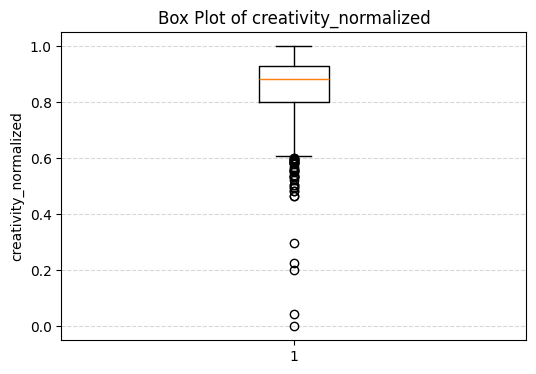

In [170]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [171]:
percentile = (creativity_normalized <= 0.85).mean() * 100
percentile

np.float64(39.21901528013582)

In [172]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [173]:
np.sum(y)/len(y)

np.float64(0.6078098471986417)

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [175]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [176]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 57.63%
Test AUC: 0.5869565217391304
Test Precision: 0.671875
Test Recall: 0.5972222222222222
Test F1: 0.6323529411764706


In [177]:
confusion_matrix(y_test, model.predict(X_test))

array([[25, 21],
       [29, 43]])

## Splines 
Splines + Balanced + Normalized (max min)

In [178]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [179]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


In [180]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [181]:
np.sum(y)/len(y)

np.float64(0.6078098471986417)

In [182]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [183]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [184]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [185]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [186]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [187]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 49.15%
Test AUC: 0.46135265700483097
Test Precision: 0.59375
Test Recall: 0.5277777777777778
Test F1: 0.5588235294117647


In [188]:
confusion_matrix(y_test, y_pred)

array([[20, 26],
       [34, 38]])

## Neural Network

In [189]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [190]:
constant = np.ones(len(surprise_df))

In [191]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [192]:
np.sum(y)/len(y)

np.float64(0.6078098471986417)

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [194]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [195]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [196]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 47.46%
Test AUC: 0.4821859903381642
Test Precision: 0.5735294117647058
Test Recall: 0.5416666666666666
Test F1: 0.5571428571428572


In [197]:
confusion_matrix(y_test, y_pred)

array([[17, 29],
       [33, 39]])

# Cut off 0.80

## Basic
Balanced + Normalized (max min)

In [198]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [199]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [200]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [201]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [202]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


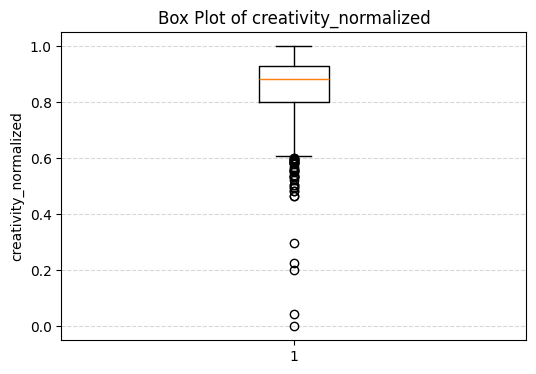

In [203]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [204]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [205]:
np.sum(y)/len(y)

np.float64(0.7538200339558574)

In [206]:
percentile = (creativity_normalized <= 0.8).mean() * 100
percentile

np.float64(24.61799660441426)

In [207]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [208]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [209]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 50.85%
Test AUC: 0.45951181712514527
Test Precision: 0.7246376811594203
Test Recall: 0.5617977528089888
Test F1: 0.6329113924050633


In [210]:
confusion_matrix(y_test, model.predict(X_test))

array([[10, 19],
       [39, 50]])

## Splines 
Splines + Balanced + Normalized (max min)

In [211]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [212]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


In [213]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [214]:
np.sum(y)/len(y)

np.float64(0.7538200339558574)

In [215]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [216]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [217]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [218]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [219]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [220]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.54%
Test AUC: 0.6280511429678419
Test Precision: 0.8113207547169812
Test Recall: 0.48314606741573035
Test F1: 0.6056338028169014


In [221]:
confusion_matrix(y_test, y_pred)

array([[19, 10],
       [46, 43]])

## Neural Network

In [222]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [223]:
constant = np.ones(len(surprise_df))

In [224]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [225]:
np.sum(y)/len(y)

np.float64(0.7538200339558574)

In [226]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [227]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [228]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [229]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 56.78%
Test AUC: 0.5699341340565672
Test Precision: 0.8064516129032258
Test Recall: 0.5617977528089888
Test F1: 0.6622516556291391


array([[17, 12],
       [39, 50]])

In [230]:
confusion_matrix(y_test, y_pred)

array([[17, 12],
       [39, 50]])

In [231]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",49.473684,0.457729,0.750000,0.500000,0.600000,"[[11, 12], [36, 36]]"
1,0.000001,"(4, 8)",49.473684,0.443841,0.722222,0.541667,0.619048,"[[8, 15], [33, 39]]"
2,0.000001,"(8, 8)",50.526316,0.538647,0.745098,0.527778,0.617886,"[[10, 13], [34, 38]]"
3,0.000001,"(8, 16)",53.684211,0.473430,0.750000,0.583333,0.656250,"[[9, 14], [30, 42]]"
4,0.000001,"(16, 16)",47.368421,0.473430,0.729167,0.486111,0.583333,"[[10, 13], [37, 35]]"
5,0.000001,"(16, 32)",49.473684,0.368357,0.706897,0.569444,0.630769,"[[6, 17], [31, 41]]"
6,0.000003,"(4, 4)",49.473684,0.457729,0.750000,0.500000,0.600000,"[[11, 12], [36, 36]]"
7,0.000003,"(4, 8)",50.526316,0.447464,0.727273,0.555556,0.629921,"[[8, 15], [32, 40]]"
8,0.000003,"(8, 8)",49.473684,0.483696,0.750000,0.500000,0.600000,"[[11, 12], [36, 36]]"
9,0.000003,"(8, 16)",53.684211,0.472826,0.750000,0.583333,0.656250,"[[9, 14], [30, 42]]"


# Cut off 0.60

## Basic
Balanced + Normalized (max min)

In [232]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [233]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [234]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [235]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [236]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


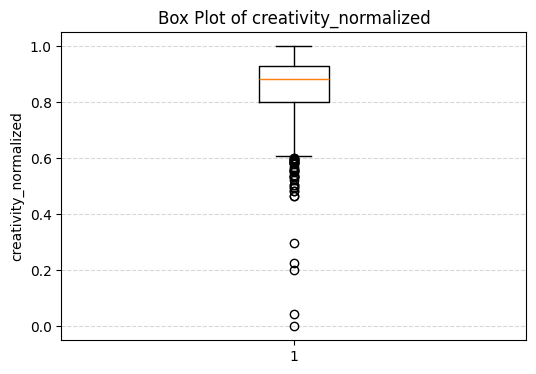

In [237]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [238]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [239]:
np.sum(y)/len(y)

np.float64(0.9354838709677419)

In [240]:
percentile = (creativity_normalized <= 0.6).mean() * 100
percentile

np.float64(6.451612903225806)

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [242]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [243]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 50.00%
Test AUC: 0.3931818181818182
Test Precision: 0.9047619047619048
Test Recall: 0.5181818181818182
Test F1: 0.6589595375722543


In [244]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 2,  6],
       [53, 57]])

## Splines 
Splines + Balanced + Normalized (max min)

In [245]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [246]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


In [247]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [248]:
np.sum(y)/len(y)

np.float64(0.9354838709677419)

In [249]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [250]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [251]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [252]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [253]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [254]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 59.32%
Test AUC: 0.5852272727272727
Test Precision: 0.9558823529411765
Test Recall: 0.5909090909090909
Test F1: 0.7303370786516854


In [255]:
confusion_matrix(y_test, y_pred)

array([[ 5,  3],
       [45, 65]])

## Neural Network

In [256]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [257]:
constant = np.ones(len(surprise_df))

In [258]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [259]:
np.sum(y)/len(y)

np.float64(0.9354838709677419)

In [260]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [261]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [262]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [263]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 42.37%
Test AUC: 0.45795454545454545
Test Precision: 0.92
Test Recall: 0.41818181818181815
Test F1: 0.575


array([[ 4,  4],
       [64, 46]])

In [264]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",36.842105,0.478464,0.939394,0.348315,0.508197,"[[4, 2], [58, 31]]"
1,0.000001,"(4, 8)",28.421053,0.554307,0.956522,0.247191,0.392857,"[[5, 1], [67, 22]]"
2,0.000001,"(8, 8)",58.947368,0.479401,0.931034,0.606742,0.734694,"[[2, 4], [35, 54]]"
3,0.000001,"(8, 16)",62.105263,0.709738,0.981818,0.606742,0.750000,"[[5, 1], [35, 54]]"
4,0.000001,"(16, 16)",69.473684,0.468165,0.941176,0.719101,0.815287,"[[2, 4], [25, 64]]"
5,0.000001,"(16, 32)",66.315789,0.430712,0.938462,0.685393,0.792208,"[[2, 4], [28, 61]]"
6,0.000003,"(4, 4)",36.842105,0.478464,0.939394,0.348315,0.508197,"[[4, 2], [58, 31]]"
7,0.000003,"(4, 8)",26.315789,0.544007,0.952381,0.224719,0.363636,"[[5, 1], [69, 20]]"
8,0.000003,"(8, 8)",60.000000,0.514981,0.932203,0.617978,0.743243,"[[2, 4], [34, 55]]"
9,0.000003,"(8, 16)",58.947368,0.668539,0.980769,0.573034,0.723404,"[[5, 1], [38, 51]]"


# Cut off 0.5

## Basic
Balanced + Normalized (max min)

In [265]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [266]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [267]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [268]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [269]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


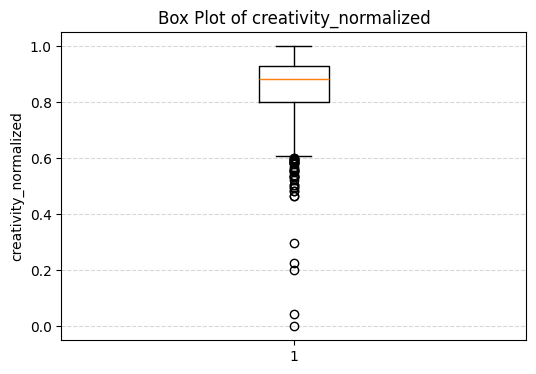

In [270]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [271]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [272]:
percentile = (creativity_normalized <= 0.5).mean() * 100
percentile

np.float64(1.8675721561969438)

In [273]:
np.sum(y)/len(y)

np.float64(0.9813242784380306)

In [274]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [275]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [276]:
print(model.classes_)

[0 1]


In [277]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 58.47%
Test AUC: 0.7241379310344828
Test Precision: 1.0
Test Recall: 0.5775862068965517
Test F1: 0.73224043715847


In [278]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 2,  0],
       [49, 67]])

## Splines 
Splines + Balanced + Normalized (max min)

In [279]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [280]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7689201013759872. Creativity Max: 0.989937998764734.


In [281]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [282]:
np.sum(y)/len(y)

np.float64(0.9813242784380306)

In [283]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [284]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [285]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [286]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [287]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [288]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 55.93%
Test AUC: 0.21982758620689652
Test Precision: 0.9705882352941176
Test Recall: 0.5689655172413793
Test F1: 0.717391304347826


In [289]:
confusion_matrix(y_test, y_pred)

array([[ 0,  2],
       [50, 66]])

## Neural Network

In [290]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [291]:
constant = np.ones(len(surprise_df))

In [292]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [293]:
np.sum(y)/len(y)

np.float64(0.9813242784380306)

In [294]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [295]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [296]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)



/opt/anaconda3/envs/Creativity/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 35 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [297]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 63.56%
Test AUC: 0.1896551724137931
Test Precision: 0.974025974025974
Test Recall: 0.646551724137931
Test F1: 0.7772020725388601


array([[ 0,  2],
       [41, 75]])

In [149]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",42.105263,0.672043,1.000000,0.408602,0.580153,"[[2, 0], [55, 38]]"
1,0.000001,"(4, 8)",80.000000,0.548387,0.974359,0.817204,0.888889,"[[0, 2], [17, 76]]"
2,0.000001,"(8, 8)",86.315789,0.467742,0.976190,0.881720,0.926554,"[[0, 2], [11, 82]]"
3,0.000001,"(8, 16)",67.368421,0.645161,0.984375,0.677419,0.802548,"[[1, 1], [30, 63]]"
4,0.000001,"(16, 16)",52.631579,0.489247,0.980000,0.526882,0.685315,"[[1, 1], [44, 49]]"
5,0.000001,"(16, 32)",76.842105,0.473118,0.986301,0.774194,0.867470,"[[1, 1], [21, 72]]"
6,0.000003,"(4, 4)",64.210526,0.559140,0.983607,0.645161,0.779221,"[[1, 1], [33, 60]]"
7,0.000003,"(4, 8)",69.473684,0.500000,0.970588,0.709677,0.819876,"[[0, 2], [27, 66]]"
8,0.000003,"(8, 8)",70.526316,0.548387,0.985075,0.709677,0.825000,"[[1, 1], [27, 66]]"
9,0.000003,"(8, 16)",51.578947,0.478495,0.979592,0.516129,0.676056,"[[1, 1], [45, 48]]"


# What if We renormalize the data

In [146]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [147]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


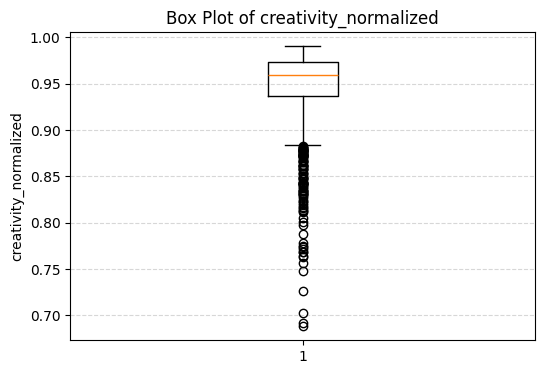

In [148]:
plt.figure(figsize=(6, 4))
plt.boxplot(creative_70, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [149]:
creative = np.array(creativity_normalized, dtype=float)
Q1 = np.percentile(creative, 25)
Q3 = np.percentile(creative, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
creative_outliers =creative[(creative < lower_bound) | (creative > upper_bound)]

In [150]:
np.max(creative_outliers)

np.float64(0.6433842697754195)

In [151]:
creative_new = creative[creative>=np.max(creative_outliers)]

In [152]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [153]:
np.min(creativity_normalized)

np.float64(0.0)

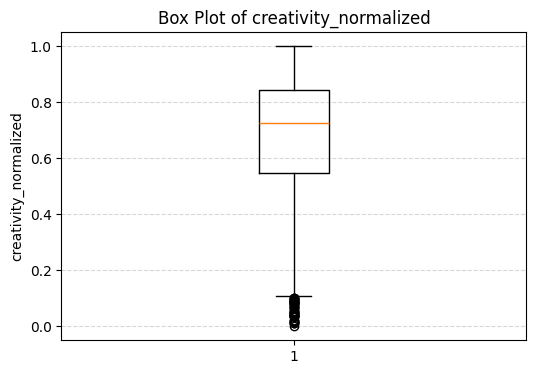

In [154]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [155]:
np.percentile(creativity_normalized, 50)

np.float64(0.7243554029776417)

## Cut off 0.7

### Basic
Balanced + Normalized (max min)

In [156]:
newness_df_new = newness_df[creative>=np.max(creative_outliers)]

In [157]:
newness_df_new.shape

(1775,)

In [158]:
newness_min=np.min(newness_df_new)
newness_max = np.max(newness_df_new)
newness_normalized=(newness_df_new - newness_min)/(newness_max-newness_min)

In [159]:
surprise_df_new = surprise_df[creative>=np.max(creative_outliers)]

In [160]:
surprise_df_new.shape

(1775,)

In [161]:
surprise_min=np.min(surprise_df_new)
surprise_max = np.max(surprise_df_new)
surprise_normalized=(surprise_df_new - surprise_min)/(surprise_max-surprise_min)

In [162]:
value_df_new = value_df[creative>=np.max(creative_outliers)]

In [163]:
value_df_new.shape

(1775,)

In [164]:
value_min=np.min(value_df_new)
value_max = np.max(value_df_new)
value_normalized=(value_df_new - value_min)/(value_max-value_min)

In [165]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [166]:
creativity_normalized.shape

(1775,)

In [167]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6433842697754195. Creativity Max: 1.0.


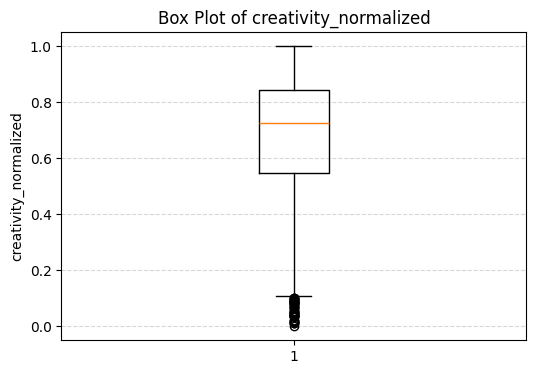

In [168]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [169]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [170]:
np.sum(y)/len(y)

np.float64(0.5504225352112676)

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [172]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [173]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 50.70%
Test AUC: 0.484102564102564
Test Precision: 0.553763440860215
Test Recall: 0.5282051282051282
Test F1: 0.5406824146981627


In [174]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 77,  83],
       [ 92, 103]])

## Splines 
Splines + Balanced + Normalized (max min)

In [175]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [176]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


In [177]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [178]:
np.sum(y)/len(y)

np.float64(0.9071504802561366)

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [180]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [181]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [182]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [183]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [184]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.53%
Test AUC: 0.3785714285714285
Test Precision: 0.875
Test Recall: 0.5558823529411765
Test F1: 0.6798561151079137


In [185]:
confusion_matrix(y_test, y_pred)

array([[  8,  27],
       [151, 189]])

## Neural Network

In [186]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [187]:
constant = np.ones(len(surprise_df))

In [188]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [189]:
np.sum(y)/len(y)

np.float64(0.9071504802561366)

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [191]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [192]:
result=[]
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight = sample_weights)
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:,1]
        acc = accuracy_score(y_test,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_test, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_test,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_test, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_test, y_pred)
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_test, y_pred)})
        #print("Test F1:", f1)


In [193]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",58.933333,0.529412,0.918919,0.600000,0.725979,"[[17, 18], [136, 204]]"
1,0.000001,"(4, 8)",64.000000,0.475798,0.905138,0.673529,0.772344,"[[11, 24], [111, 229]]"
2,0.000001,"(8, 8)",53.600000,0.484538,0.919192,0.535294,0.676580,"[[19, 16], [158, 182]]"
3,0.000001,"(8, 16)",53.066667,0.518319,0.890476,0.550000,0.680000,"[[12, 23], [153, 187]]"
4,0.000001,"(16, 16)",55.466667,0.537899,0.898618,0.573529,0.700180,"[[13, 22], [145, 195]]"
5,0.000001,"(16, 32)",60.800000,0.493361,0.910638,0.629412,0.744348,"[[14, 21], [126, 214]]"
6,0.000003,"(4, 4)",58.933333,0.529412,0.918919,0.600000,0.725979,"[[17, 18], [136, 204]]"
7,0.000003,"(4, 8)",53.600000,0.483950,0.919192,0.535294,0.676580,"[[19, 16], [158, 182]]"
8,0.000003,"(8, 8)",53.600000,0.484538,0.919192,0.535294,0.676580,"[[19, 16], [158, 182]]"
9,0.000003,"(8, 16)",61.866667,0.502101,0.902041,0.650000,0.755556,"[[11, 24], [119, 221]]"
